M1-M4 are the assumed models. M5-M12 are observation data-generating processes.

DeepSet, 4*num_dim, 10 observation,DeepSet,epochs=256, inference network: depth=8, widths=(256,256,256), "norm": "layer", larger training budget for M3

In [1]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
sd.quiet_bayesflow_progress()

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 10
num_datasets = 50
num_samples = 1000
n_ref = 2000

project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_dir = project_dir / "results" / "ood_80d_10n"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},

    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},

    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
#pd.DataFrame(source_specs).T

In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [4]:
# get raw datasets
raw_dataset_dir=project_dir / "results" / "ood_20d_10n"/"datasets"
datasets = {source: load_pickle(raw_dataset_dir / f"{source}_raw.pkl") for source in sd.SOURCE_MODELS}

In [5]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_80d_10n.keras"
filepath_m2 = network_dir / "m2_s_80d_10n.keras"
filepath_m3 = network_dir / "m3_s_80d_10n.keras"
filepath_m4 = network_dir / "m4_s_80d_10n.keras"
filepath_direct = network_dir / "direct_s_20d_10n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [6]:
# Compute logmls and PMPs
calculation_m1 = Calculation(approximator=approximator_m1,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m1",)
calculation_m2 = Calculation(approximator=approximator_m2,mu_prior_mean=3.0,mu_prior_std=1.0,
    num_dims=num_dims,num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m2",)
calculation_m3 = Calculation(approximator=approximator_m3,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=3.0,num_samples=num_samples,assumed_model="m3",)
calculation_m4 = Calculation(approximator=approximator_m4,mu_prior_mean=0.1,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m4",)

calculations = {"m1": calculation_m1, "m2": calculation_m2, "m3": calculation_m3, "m4": calculation_m4}

In [7]:
# compute logmls and PMPs for all datasets
datasets = sd.compute_logml_and_posteriors(datasets, calculations)
datasets = sd.compute_model_probabilities(datasets, approximator_direct)

for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_logml_pmp.pkl")

print(datasets["m1"][0].keys())

dict_keys(['mu', 'x', 'id', 'source_model', 'gold_log_marginal_m1', 'gold_post_samples_m1', 'npe_post_samples_m1', 'npe_log_marginal_m1', 'npe_log_marginal_gp_m1', 'gold_log_marginal_m2', 'gold_post_samples_m2', 'npe_post_samples_m2', 'npe_log_marginal_m2', 'npe_log_marginal_gp_m2', 'gold_log_marginal_m3', 'gold_post_samples_m3', 'npe_post_samples_m3', 'npe_log_marginal_m3', 'npe_log_marginal_gp_m3', 'gold_log_marginal_m4', 'gold_post_samples_m4', 'npe_post_samples_m4', 'npe_log_marginal_m4', 'npe_log_marginal_gp_m4', 'p_direct', 'p_gold', 'p_npe'])


In [ ]:
datasets = {source: load_pickle(dataset_dir / f"{source}_logml_pmp.pkl") for source in sd.SOURCE_MODELS}

In [8]:
# Fit summary-space reference distributions
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS) 
}
distance_metric = "l2"
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref, distance_metric=distance_metric,alpha=0.1)
pd.DataFrame({k: {"metric": v["distance_metric"], "summary_dim": v["summary_dim"], "dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,metric,summary_dim,dm_low,dm_high,median
m1,l2,80,0.496855,0.737945,0.579589
m2,l2,80,0.503489,0.7582,0.58662
m3,l2,80,0.506685,0.885927,0.644356
m4,l2,80,0.501498,0.750106,0.579469


In [9]:
# Add dynamic distance regimes and x(y) score
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

posterior_df = sd.collect_posterior_distance_frame(datasets, n_samples=1000)
logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
posterior_df.to_csv(result_dir / "posterior_distance_frame_80d_10n.csv", index=False)
logml_df.to_csv(result_dir / "logml_distance_frame_80d_10n.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame_80d_10n.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary_80d_10n.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary_80d_10n.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_80d_10n.pkl")


In [ ]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed_80d_10n.pkl") for source in sd.SOURCE_MODELS}
posterior_df = pd.read_csv(result_dir / "posterior_distance_frame_80d_10n.csv")
logml_df = pd.read_csv(result_dir / "logml_distance_frame_80d_10n.csv")
pmp_df = pd.read_csv(result_dir / "pmp_ambiguity_frame_80d_10n.csv")

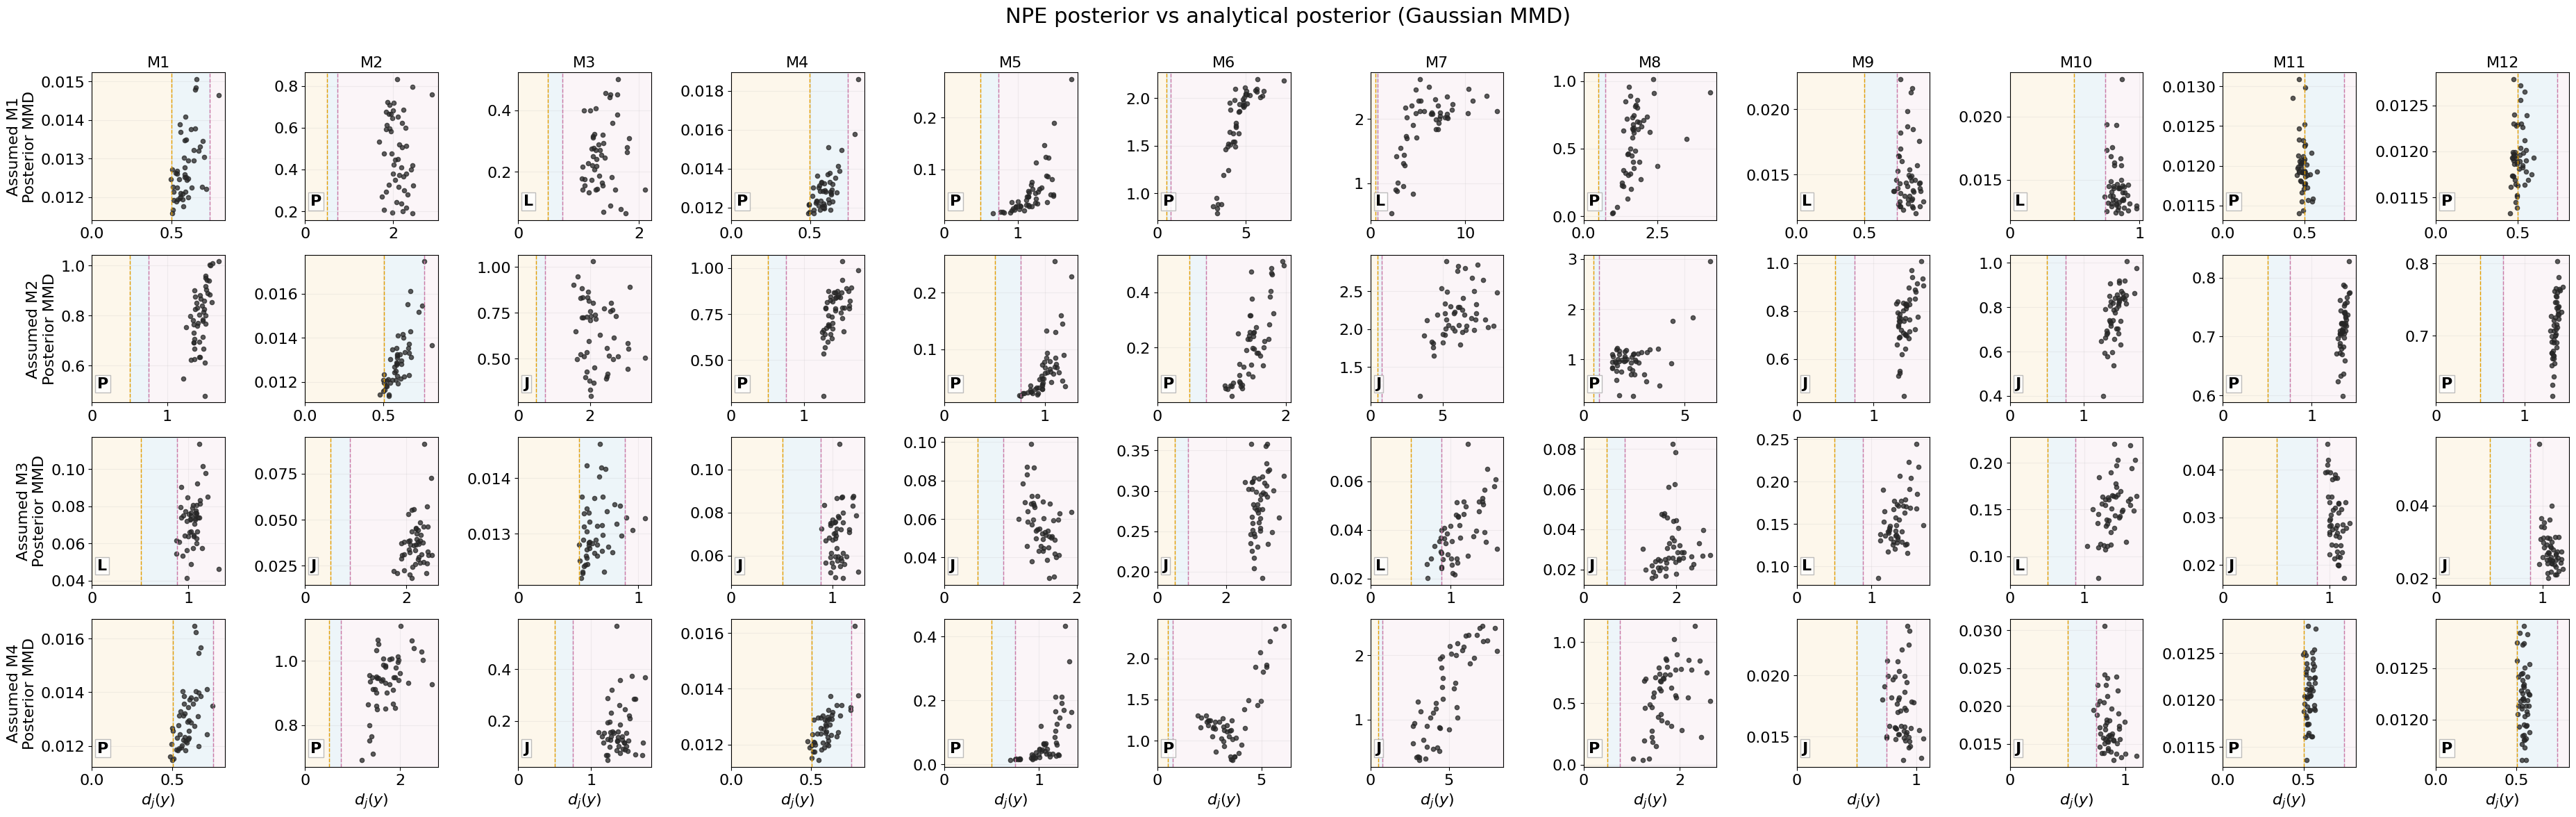

In [10]:
# Posterior MMD
sd.plot_posterior_metric_grid(
    posterior_df, metric="mmd", output_dir=figure_dir, sharey=False
);


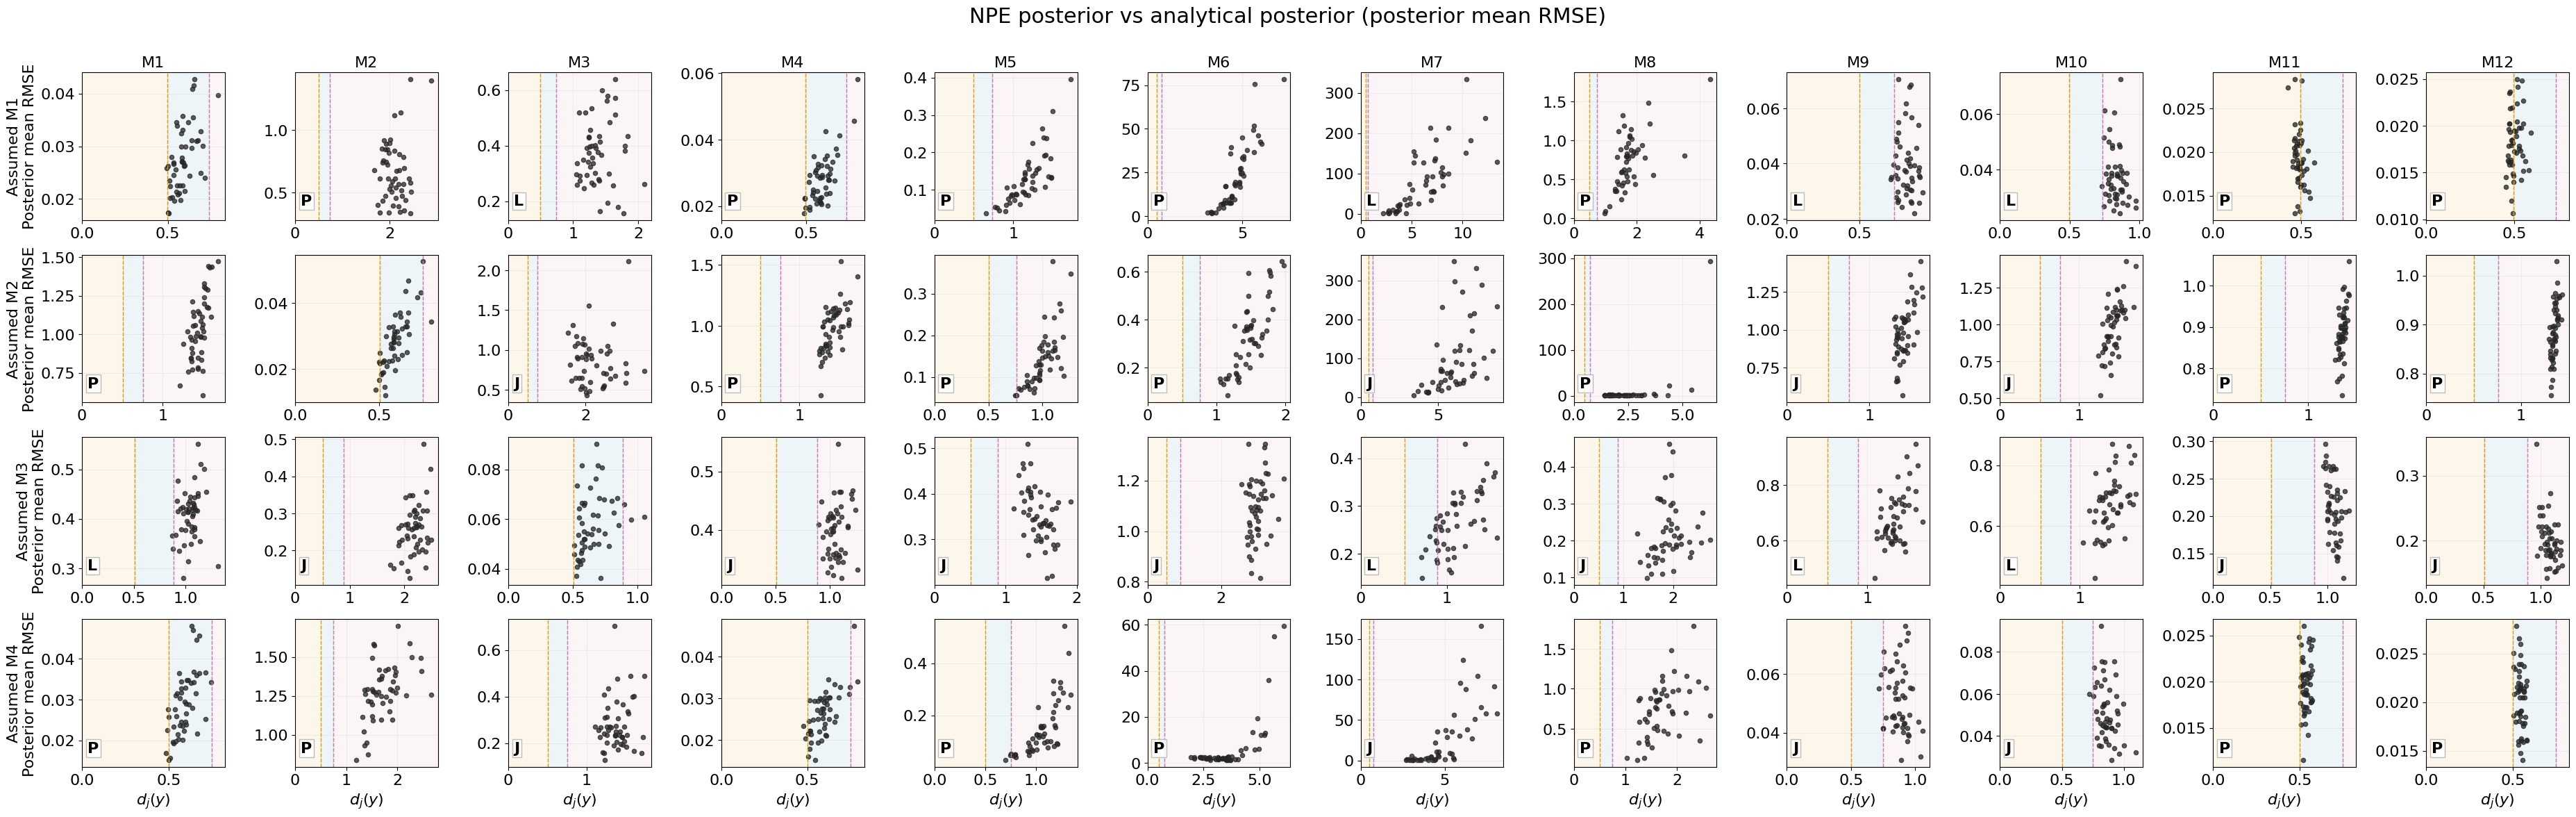

In [11]:
# Posterior RMSE
sd.plot_posterior_metric_grid(
    posterior_df, metric="mean_rmse", output_dir=figure_dir, sharey=False
);


## Plots

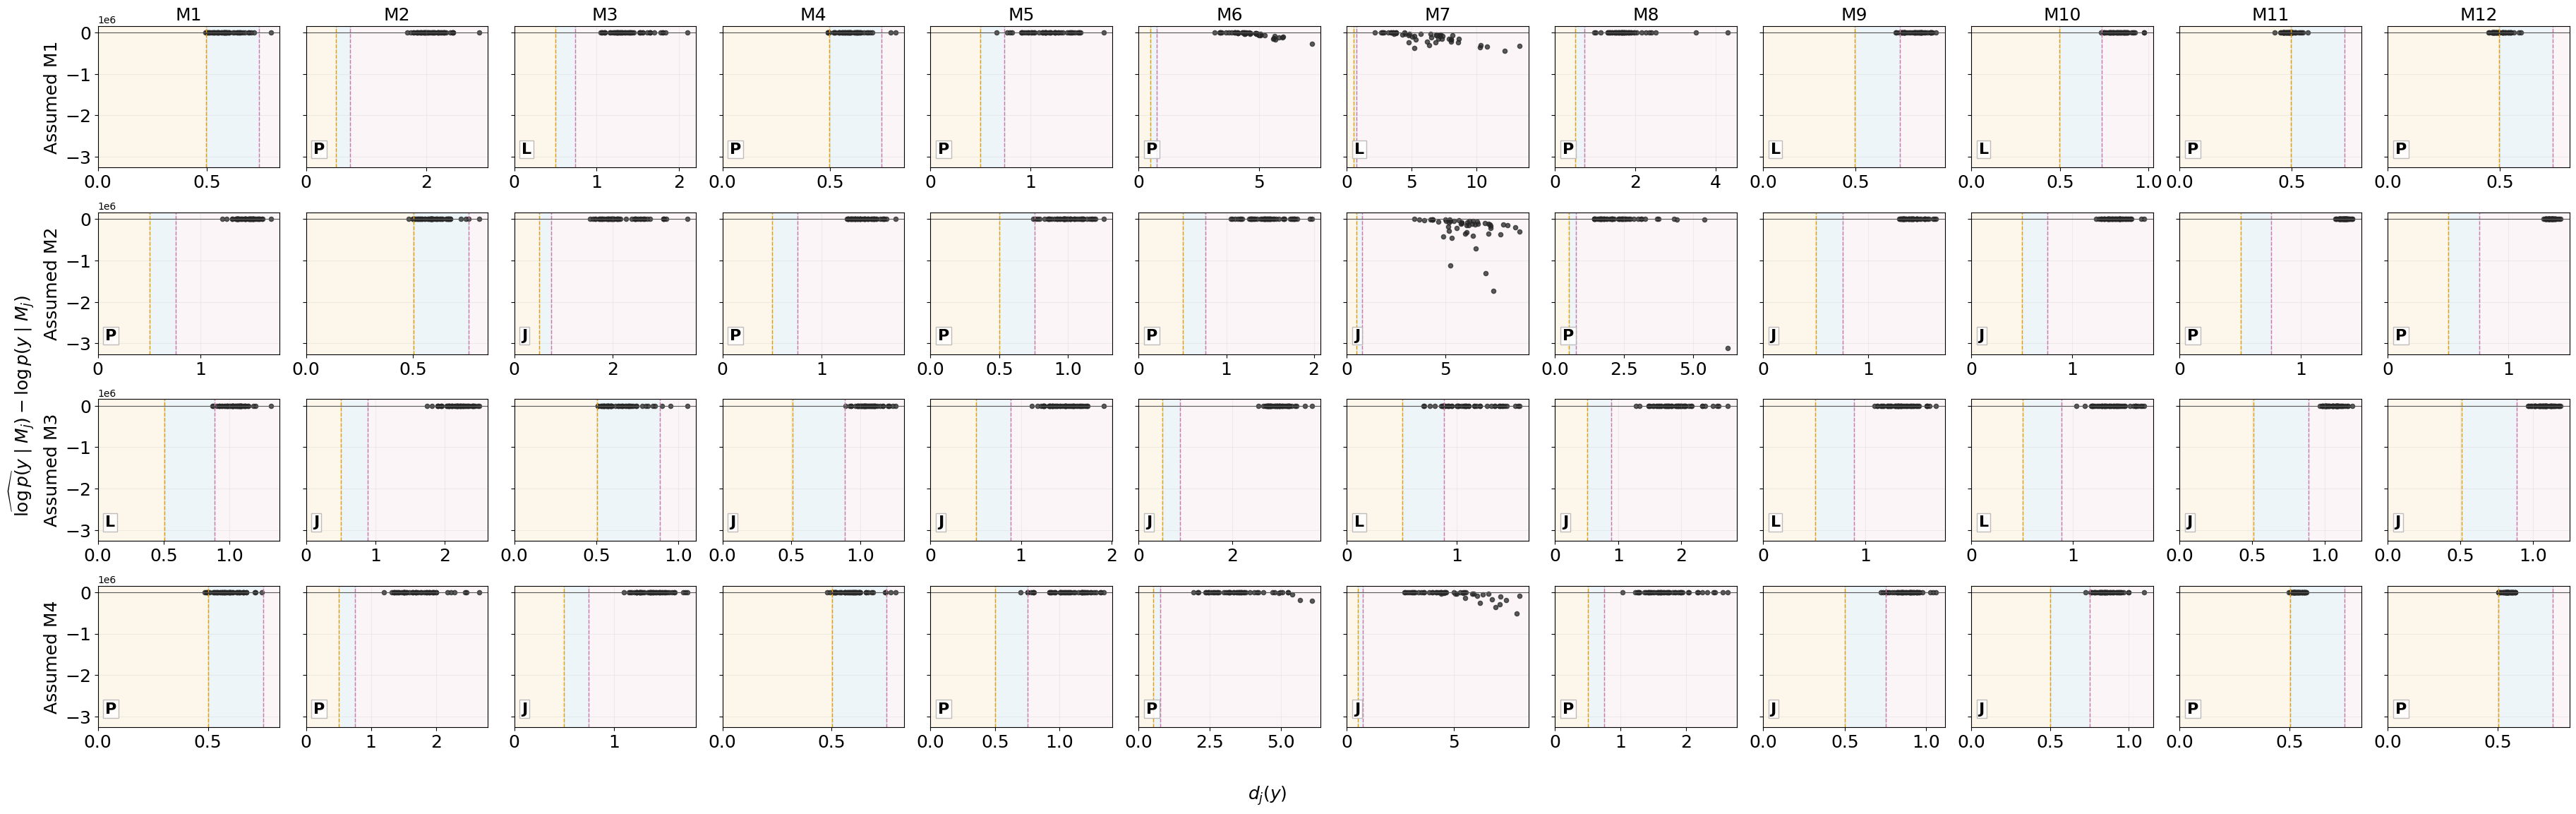

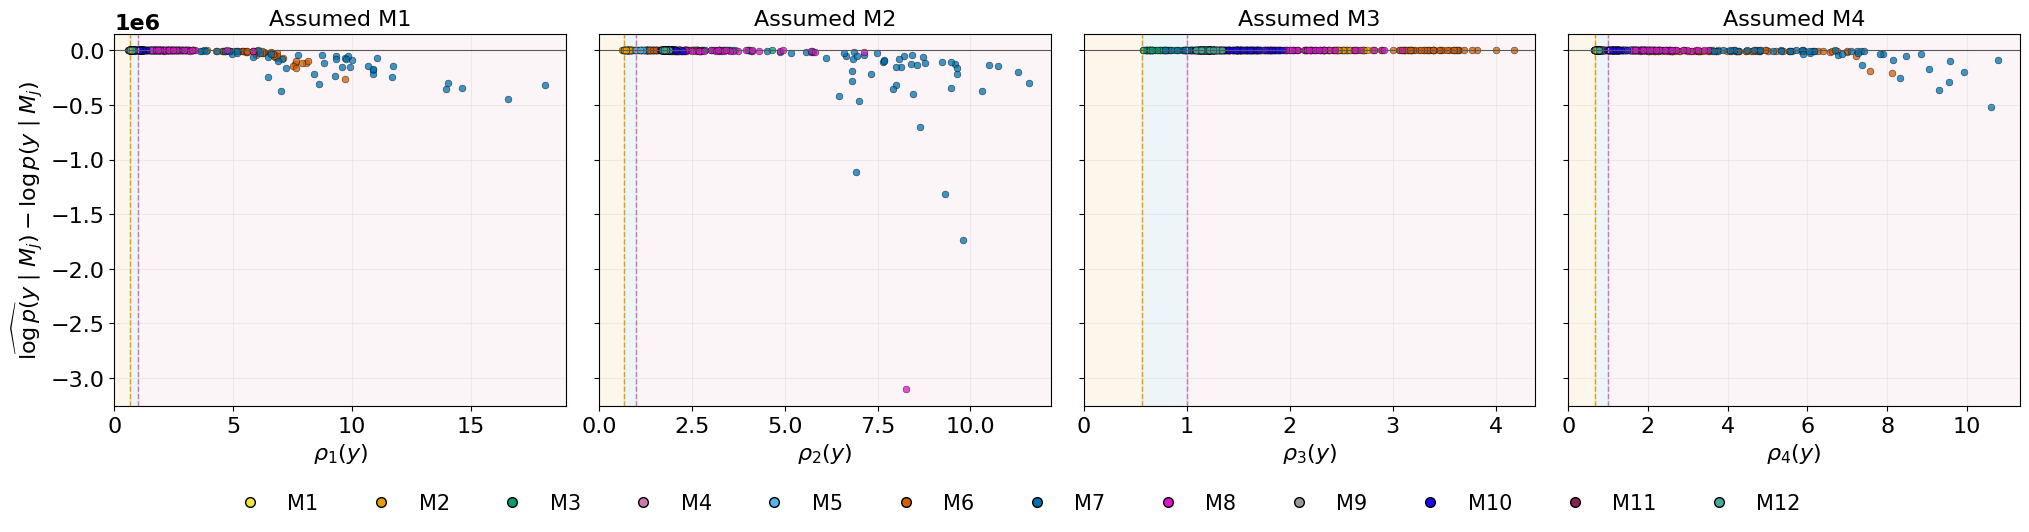

In [12]:
# signed logml error with shared y-axis
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir);
sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

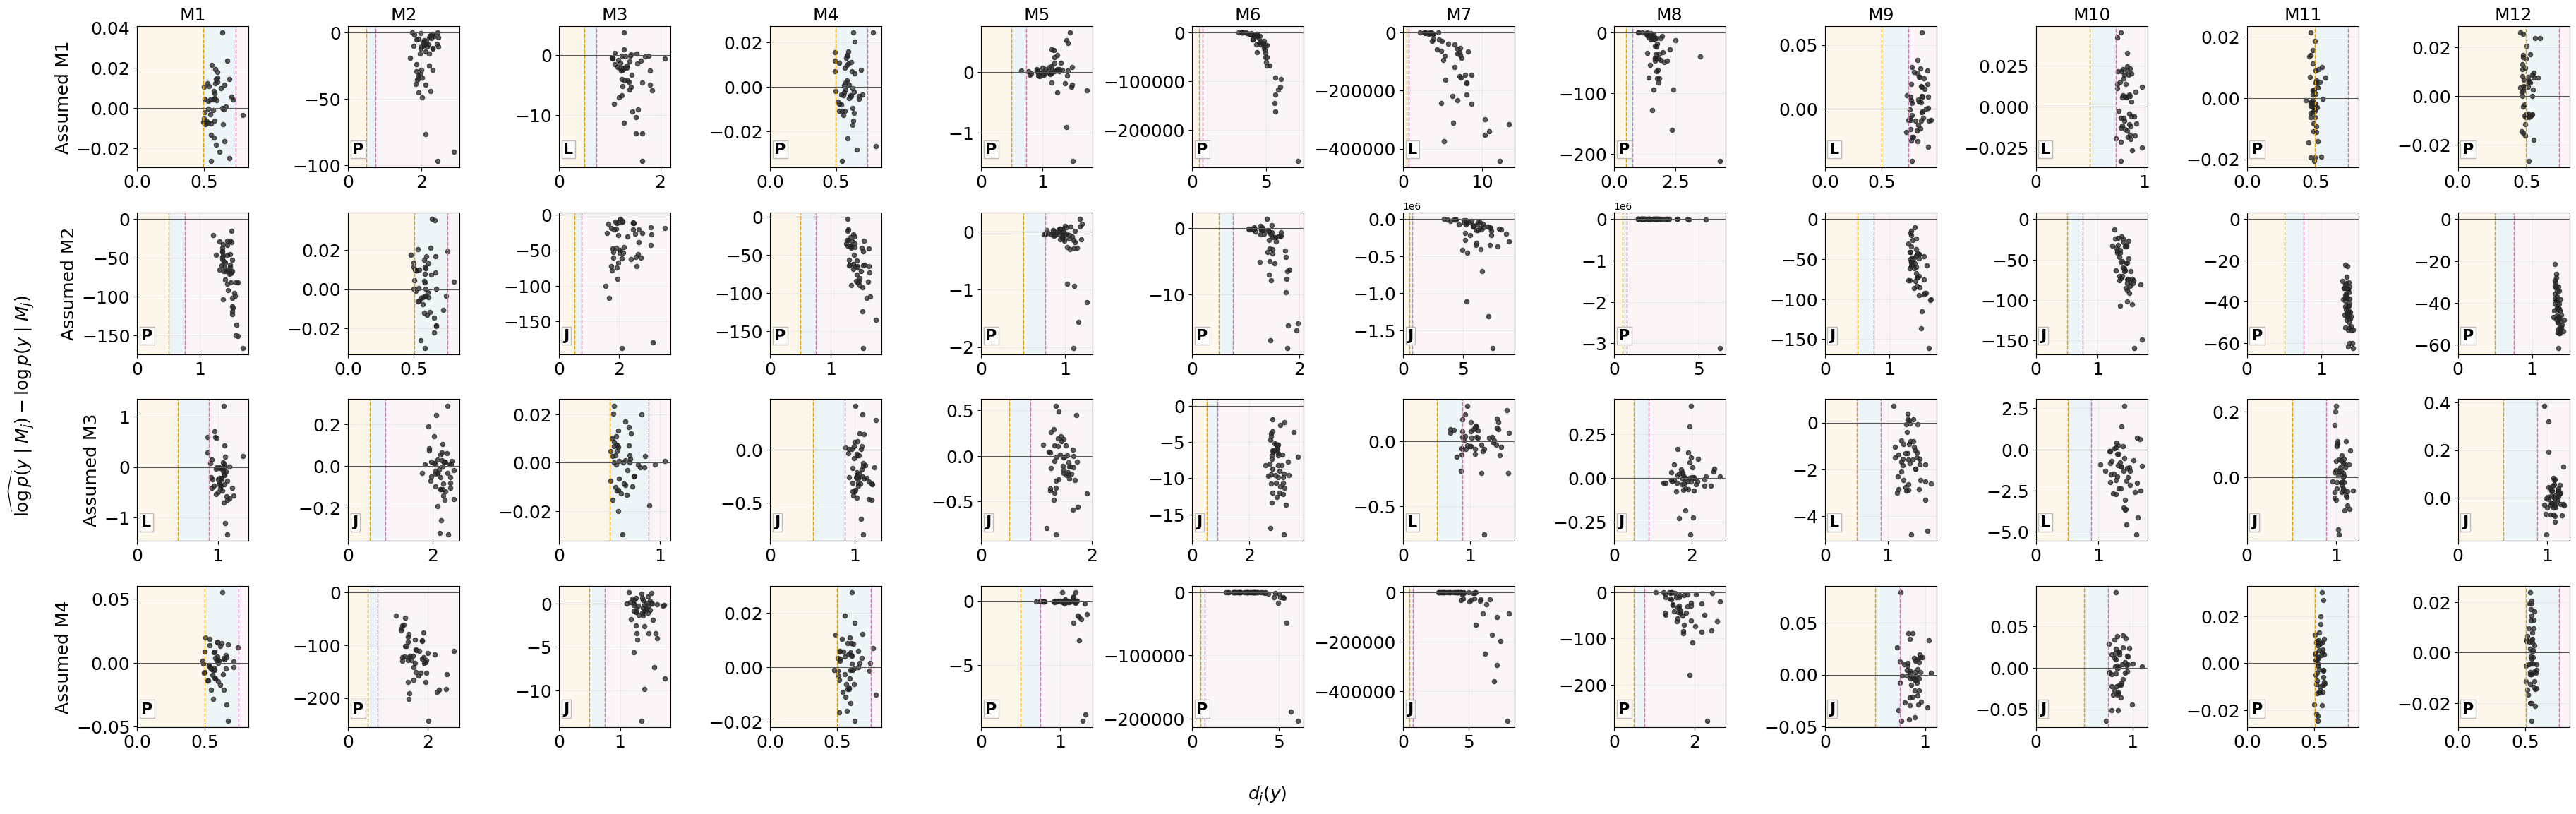

In [13]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir,sharey=False);

(<Figure size 1960x600 with 4 Axes>,
 array([<Axes: title={'center': '$p(M_1\\mid y)$'}, xlabel='$\\log(1+A(y))$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': '$p(M_2\\mid y)$'}, xlabel='$\\log(1+A(y))$'>,
        <Axes: title={'center': '$p(M_3\\mid y)$'}, xlabel='$\\log(1+A(y))$'>,
        <Axes: title={'center': '$p(M_4\\mid y)$'}, xlabel='$\\log(1+A(y))$'>],
       dtype=object))

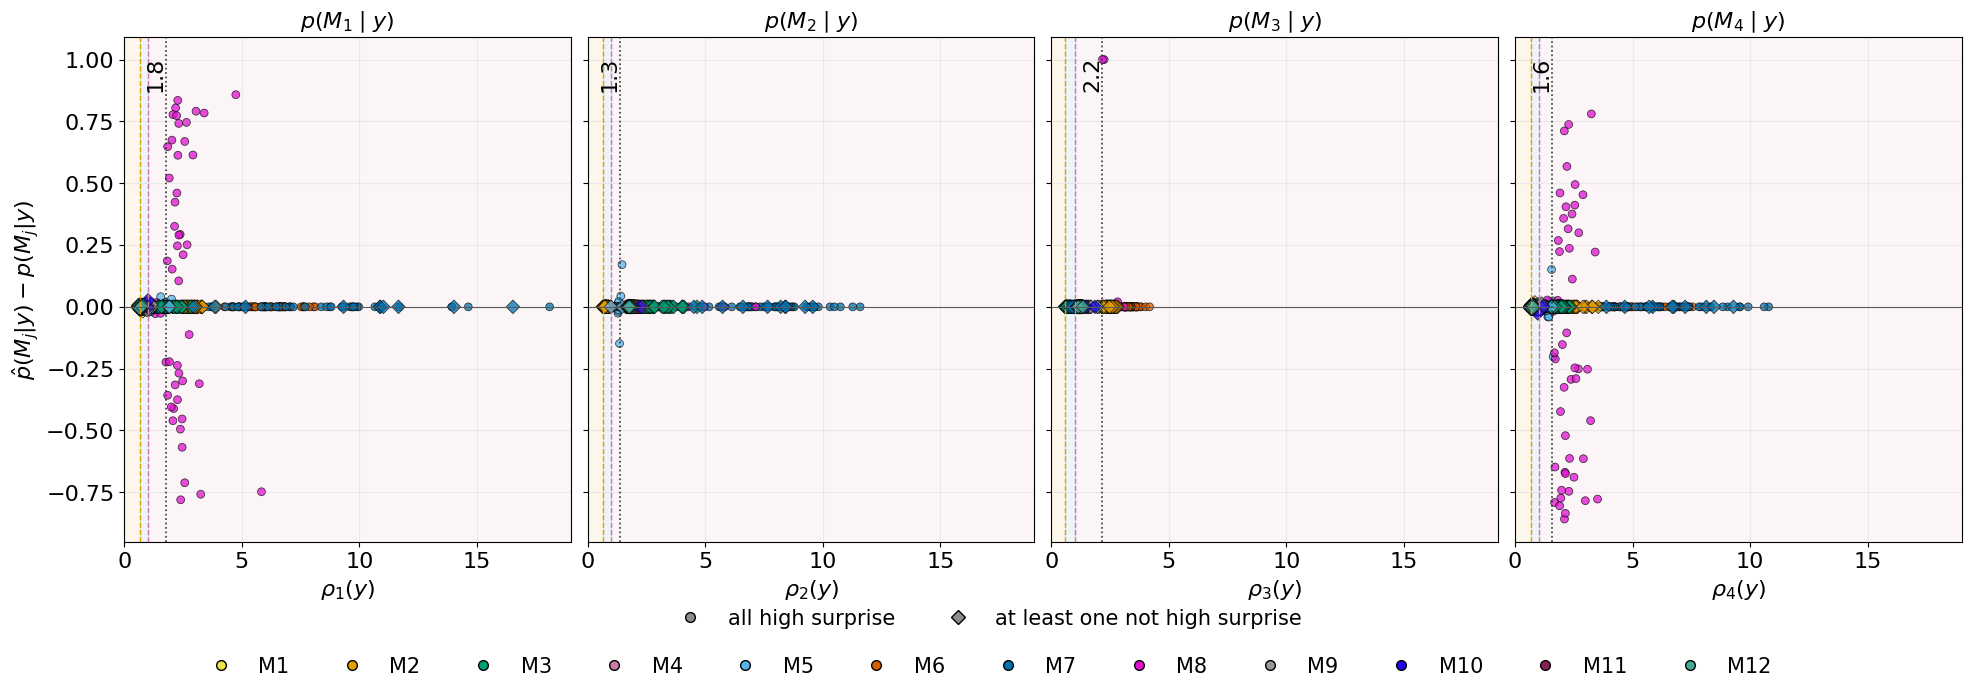

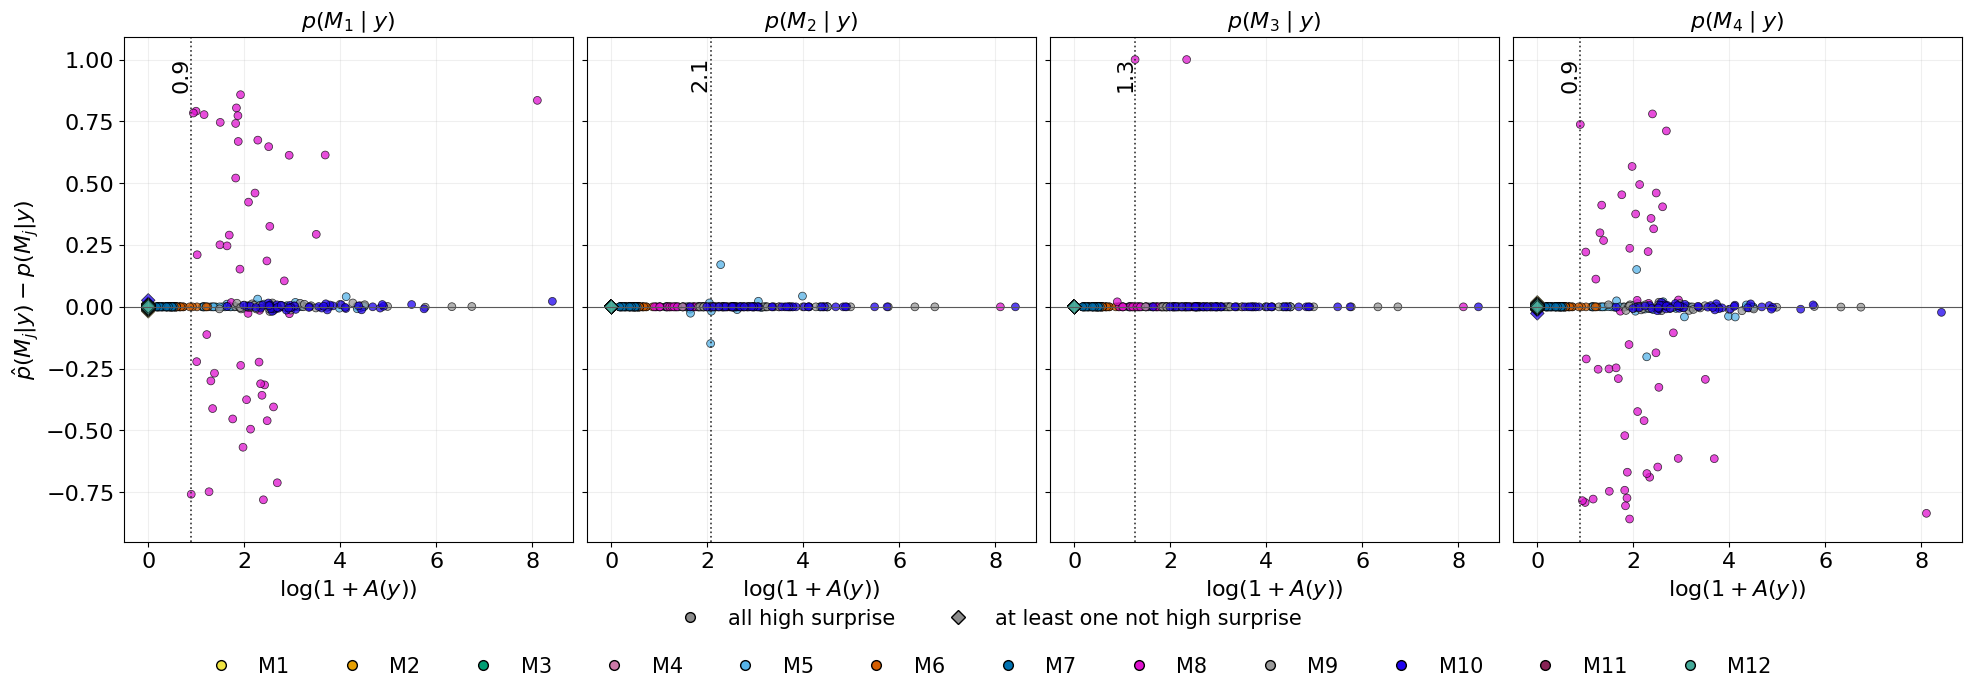

In [14]:
# PMP plots
sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",sharex=True,x_min=0.0,error_bound=0.05,)
sd.plot_pmp_diagnostic(pmp_df,x="logA",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",sharex=True,error_bound=0.05,error_subset="all_extrapolative")



In [15]:
# # PMP estimates (NPE and NPMP) vs distance for each source model
# for source in sd.SOURCE_MODELS:
#     sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

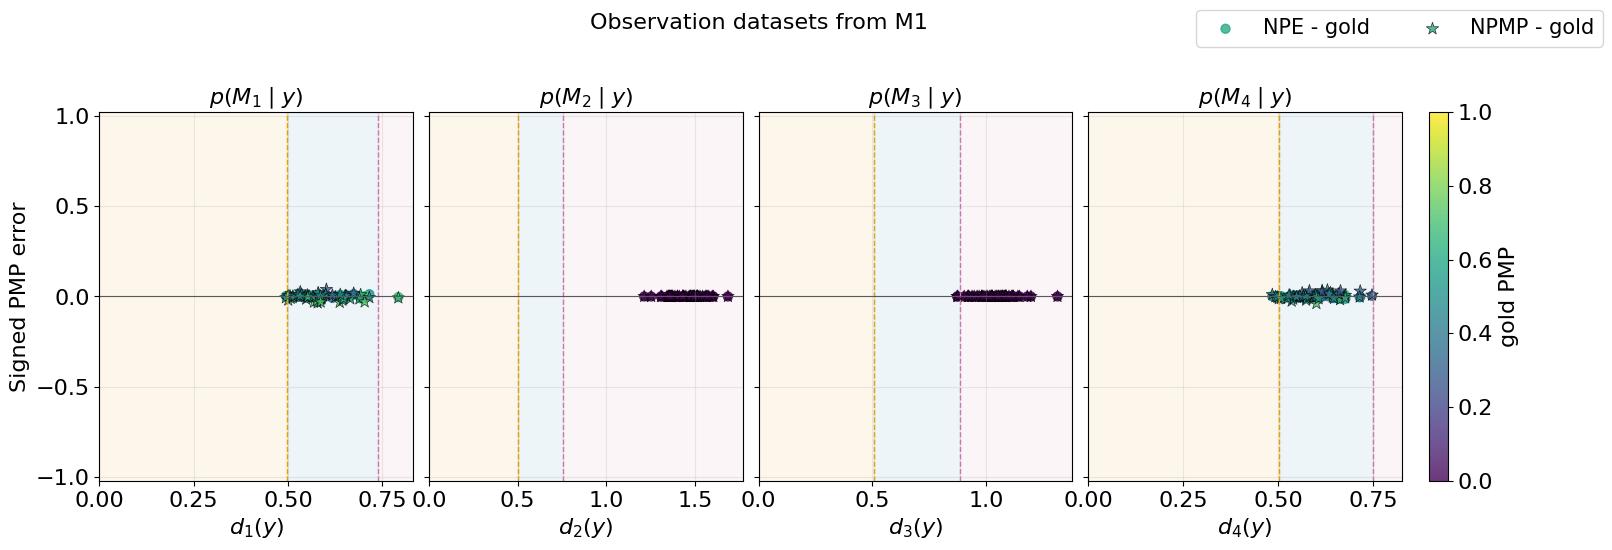

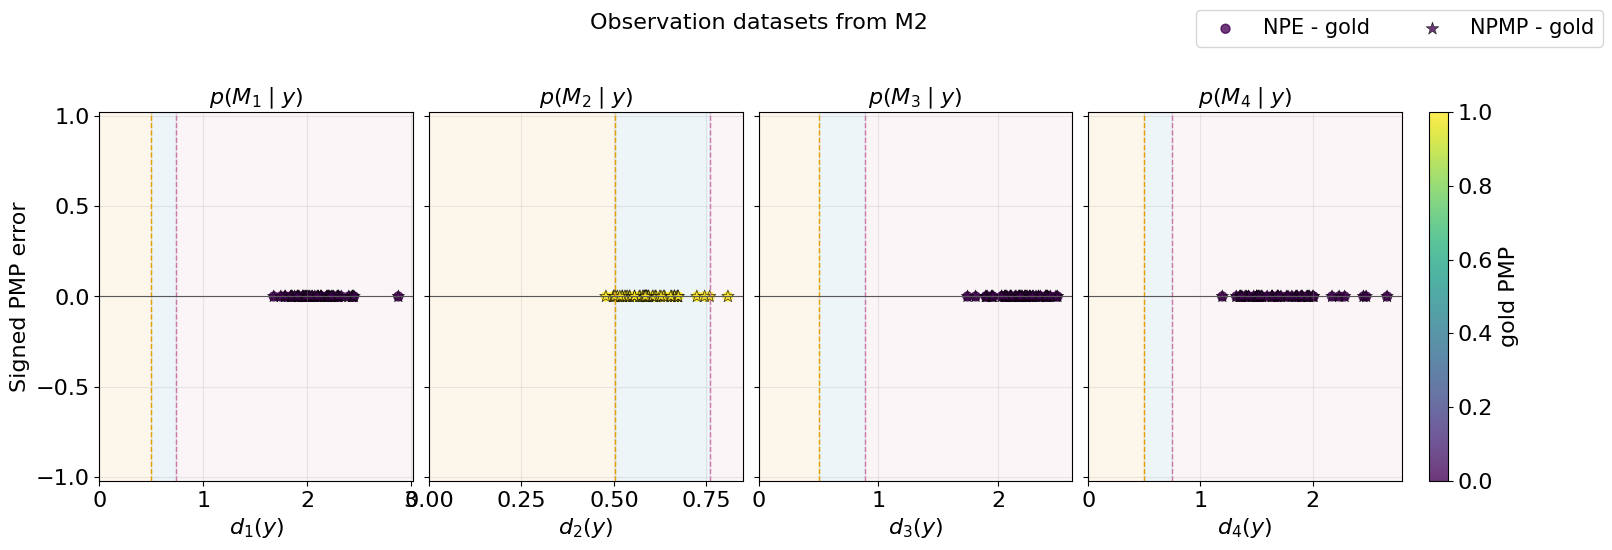

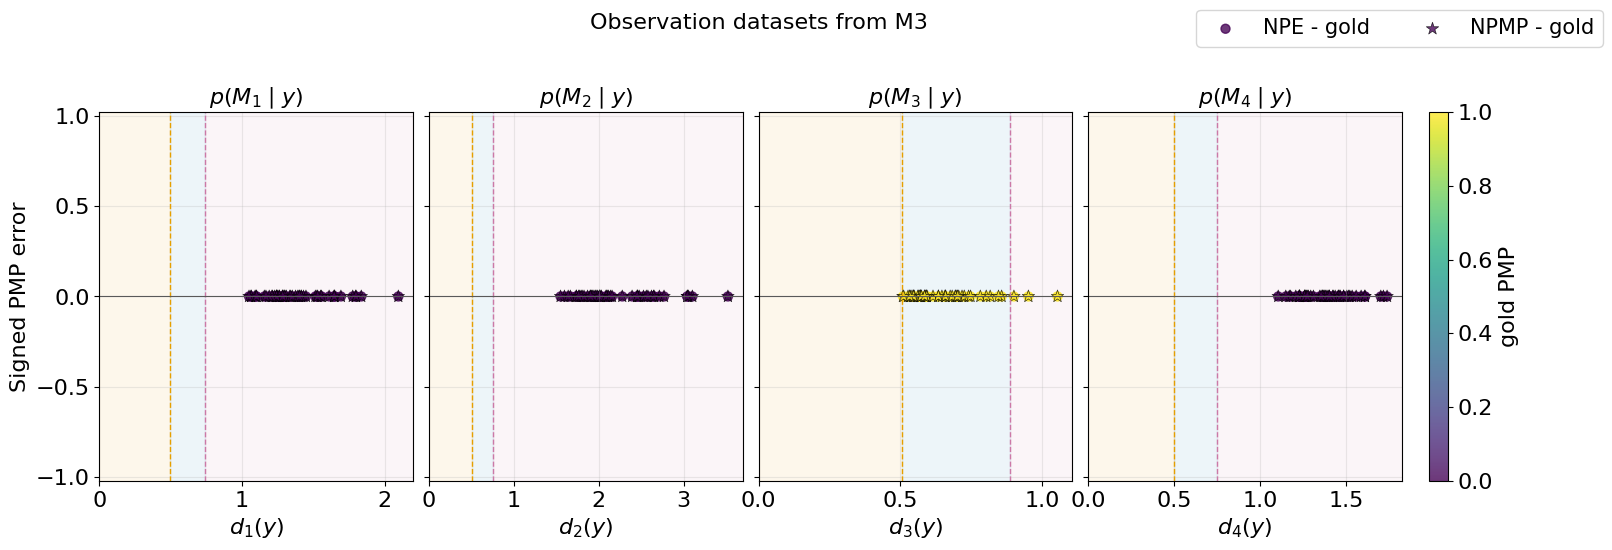

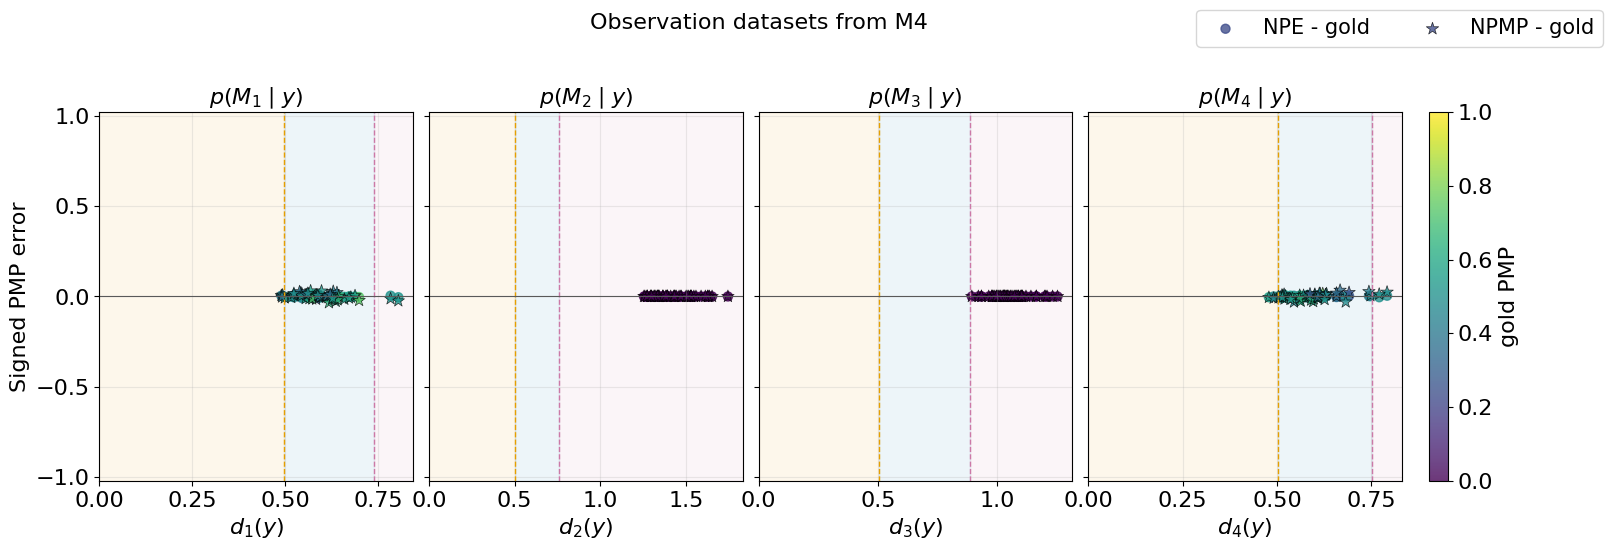

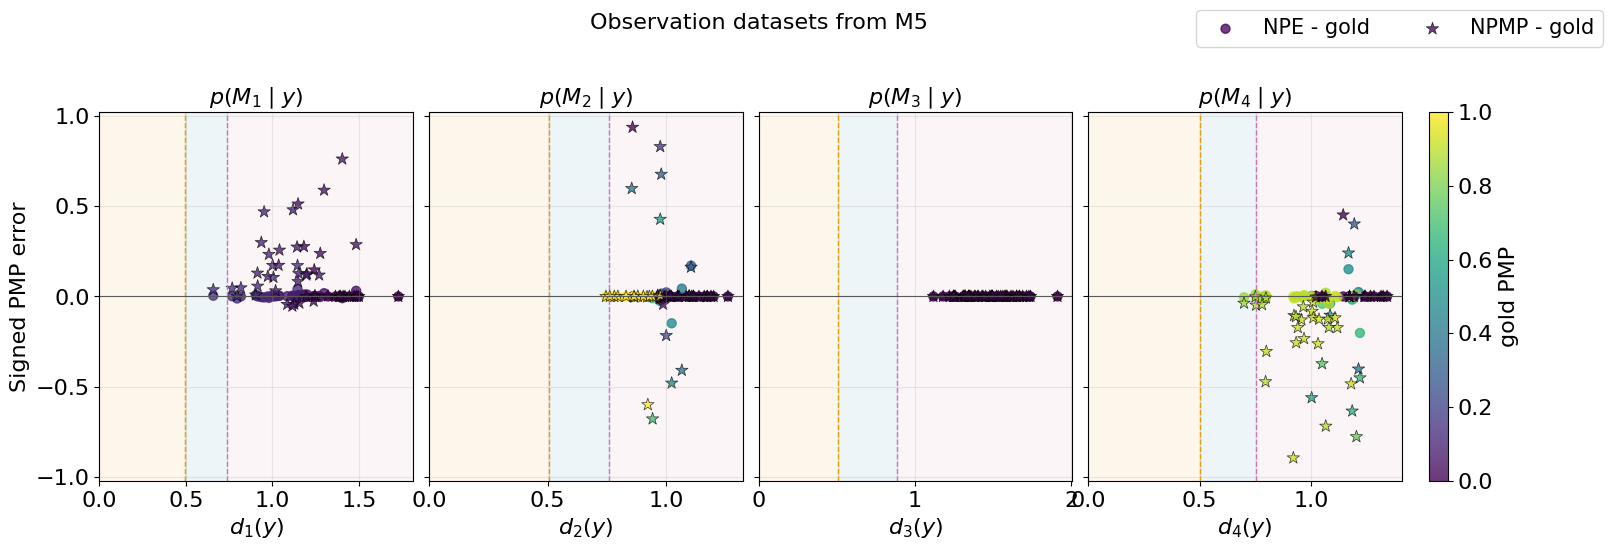

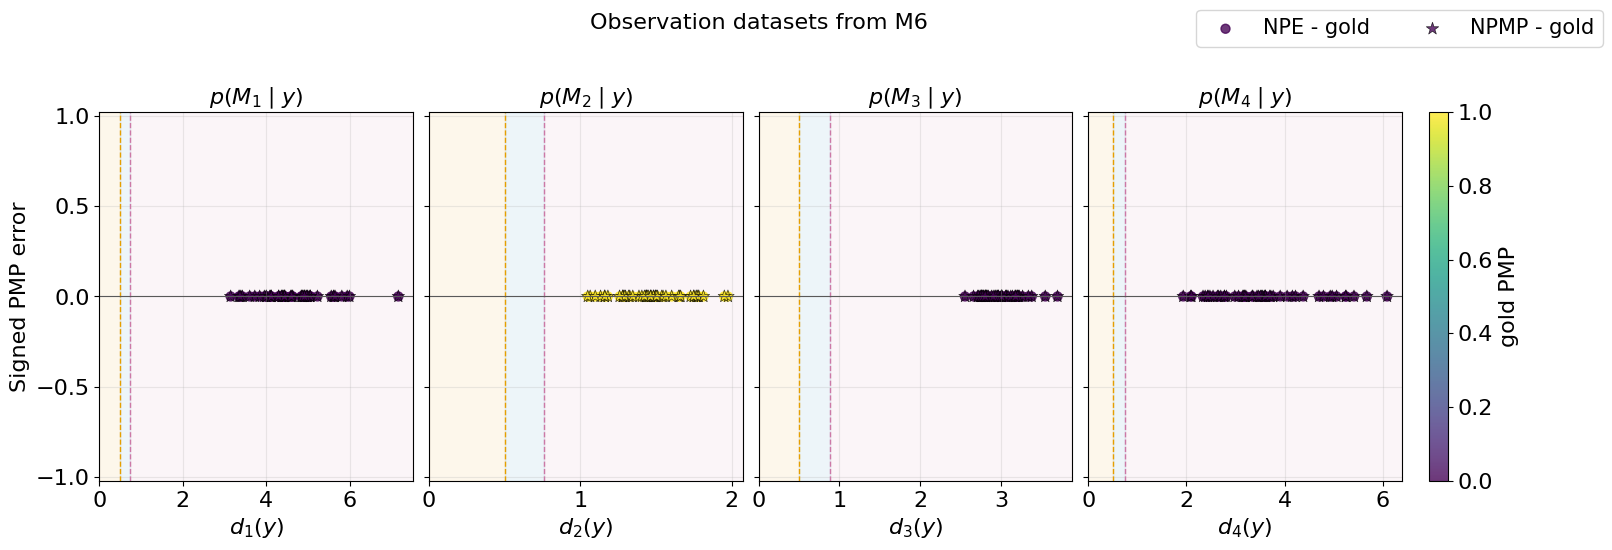

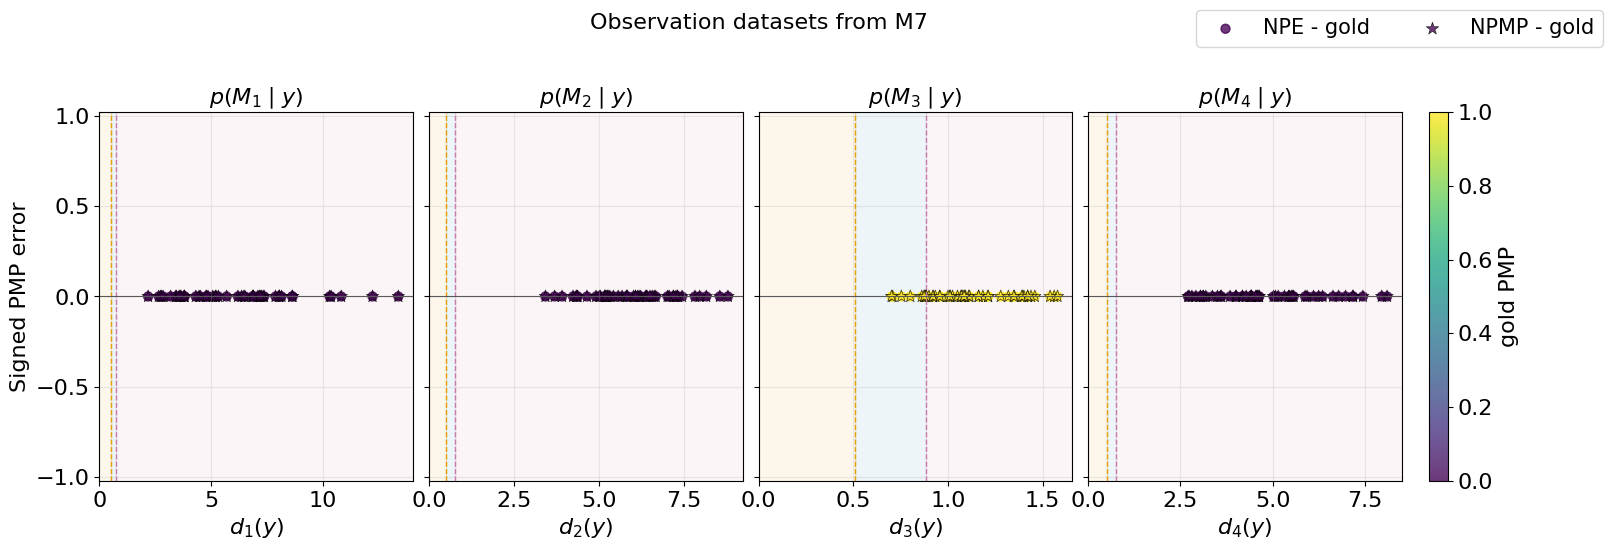

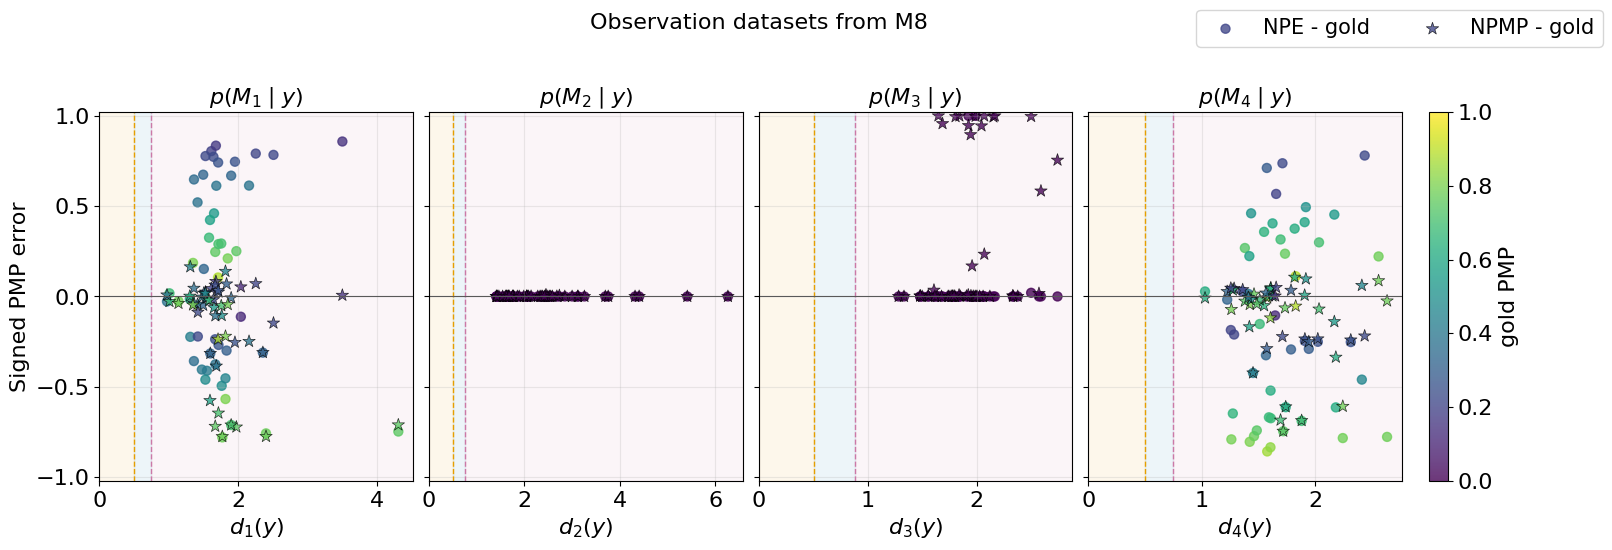

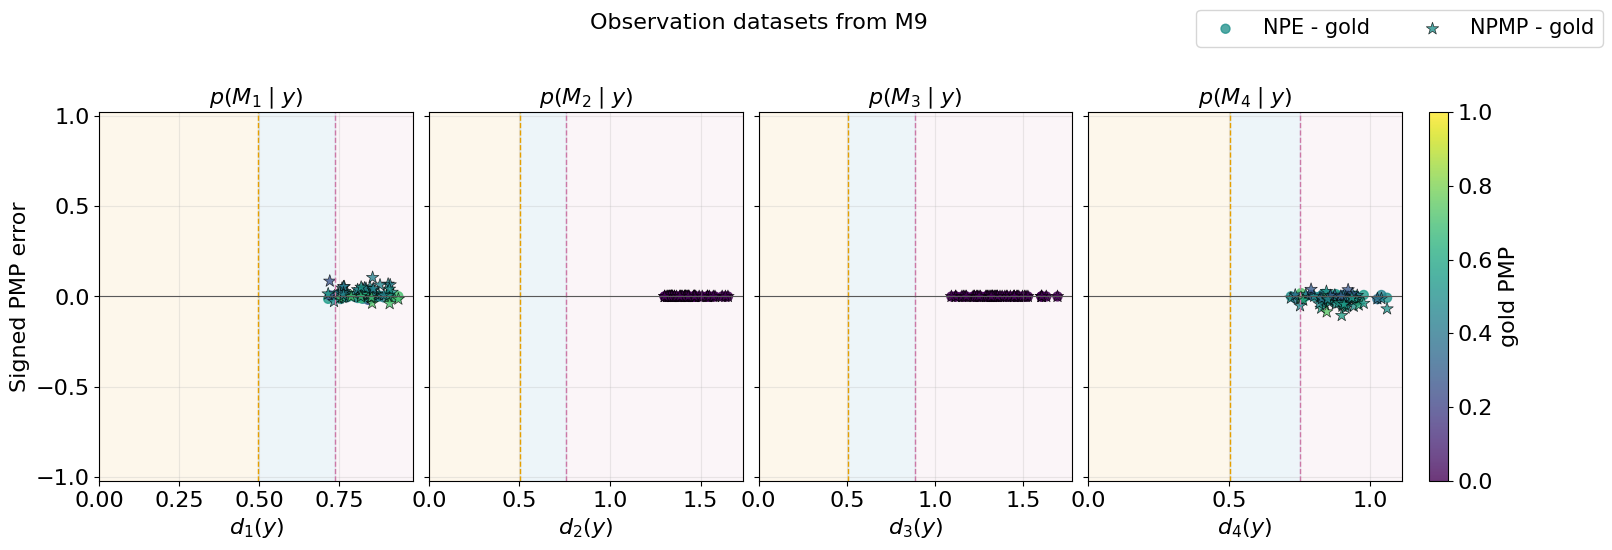

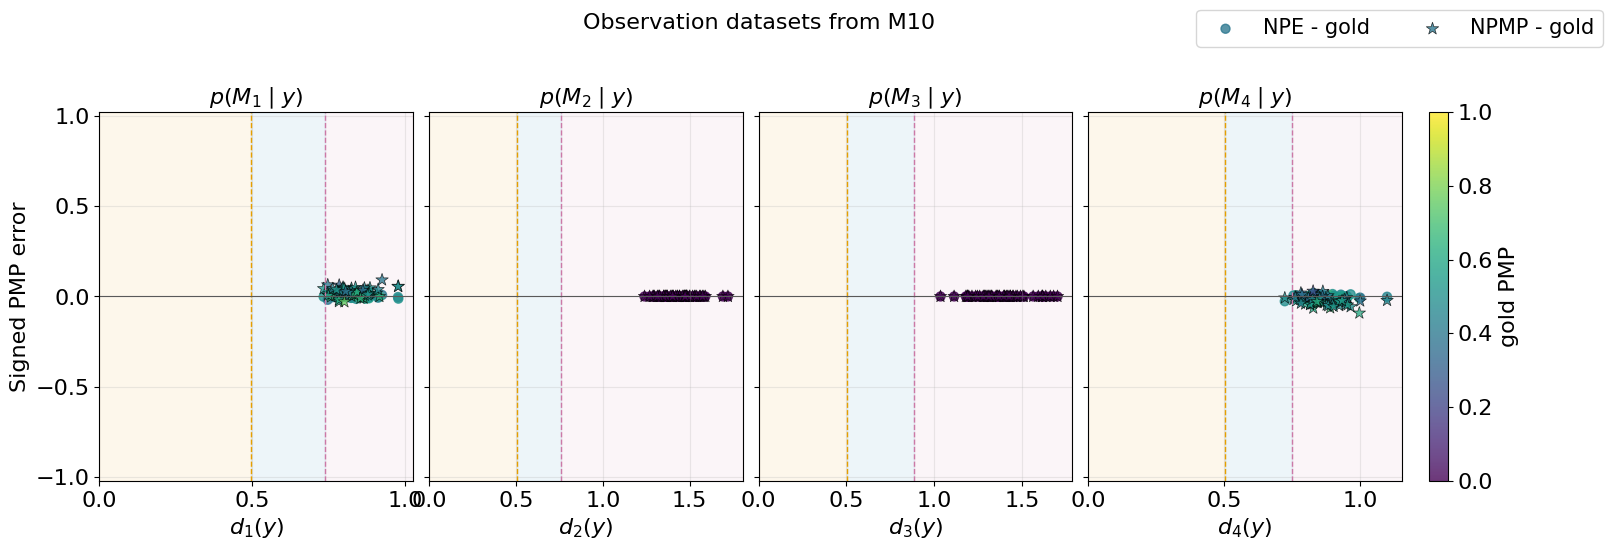

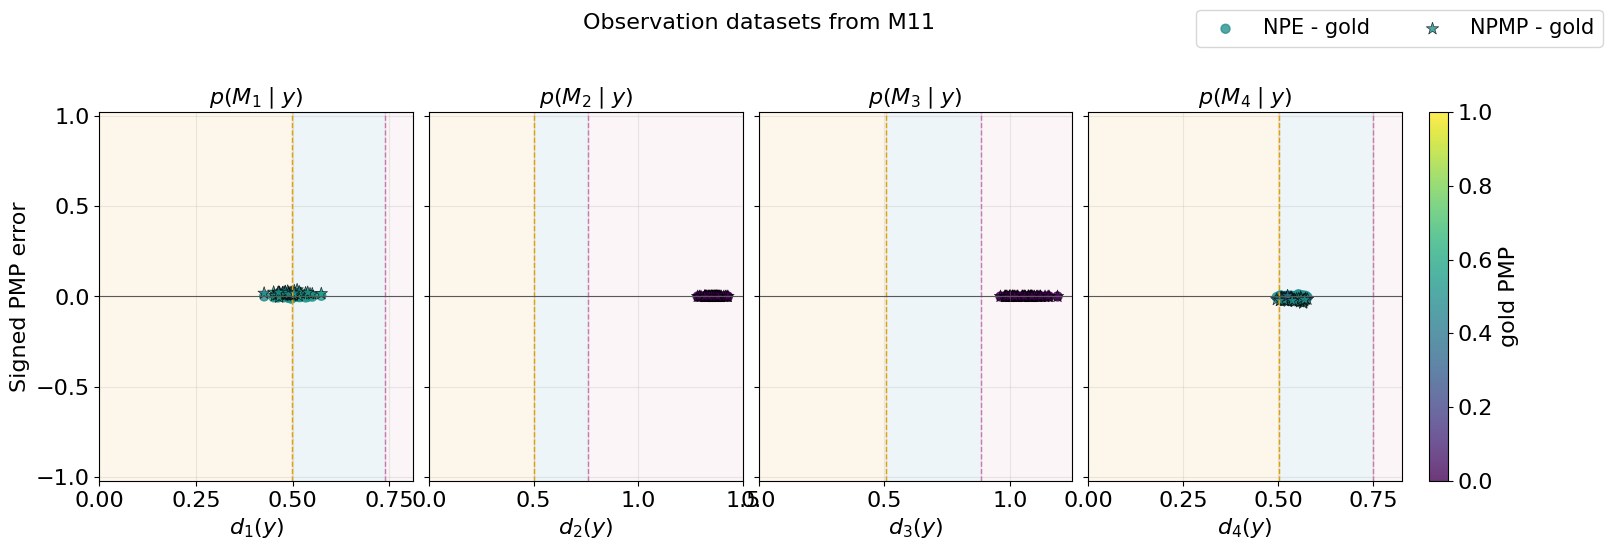

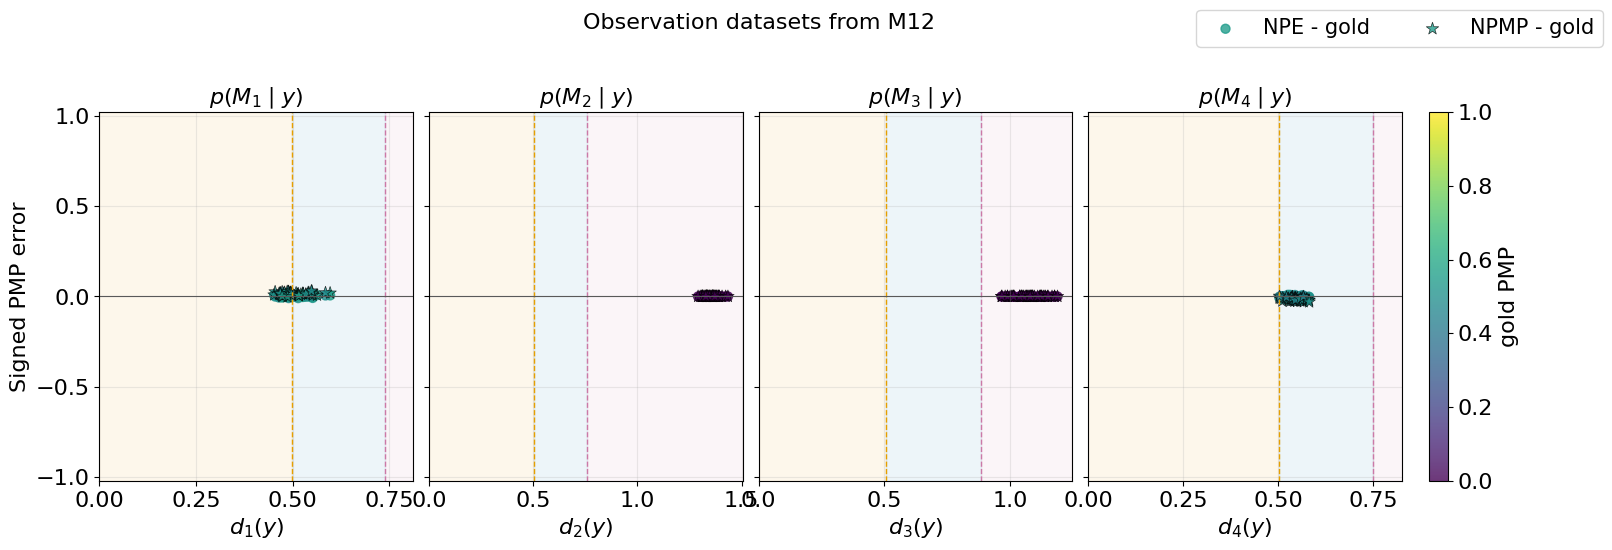

In [16]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)

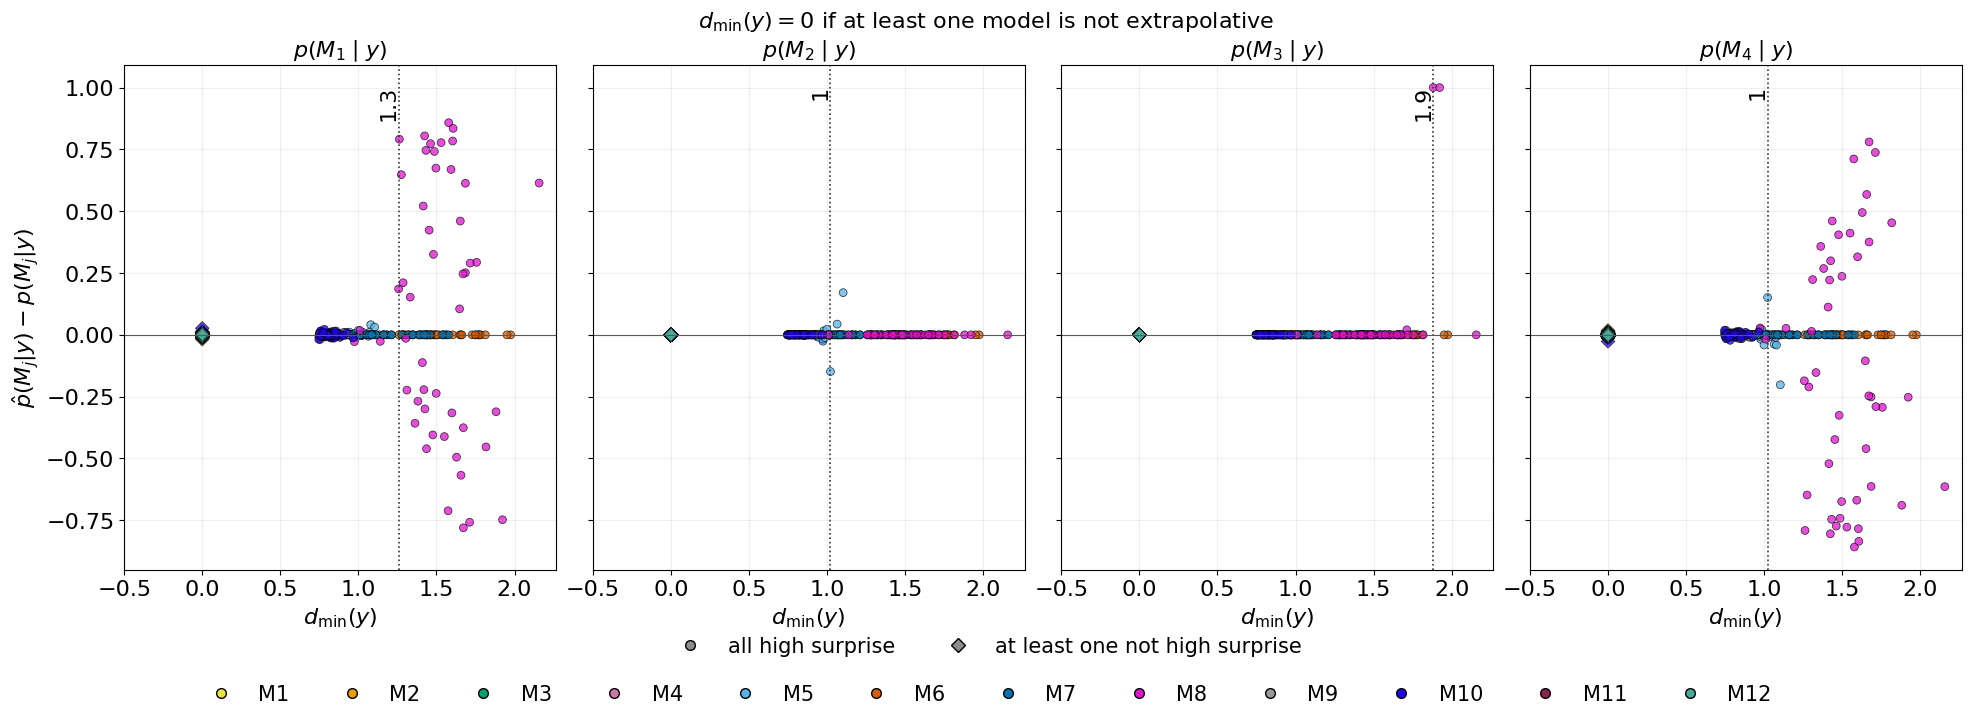

In [17]:
# Temporary diagnostic: set d_min(y) = 0 when at least one model is not extrapolative
pmp_d_min_zero = pmp_df.copy()
pmp_d_min_zero.loc[pmp_d_min_zero["at_least_one_not_extrapolative"], "d_min"] = 0.0

sd.plot_pmp_diagnostic(pmp_d_min_zero,x="d_min",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="d_min_zero_vs_pmp_error_npe.png",title=r"$d_{\min}(y)=0$ if at least one model is not extrapolative",sharex=True,x_min=-.5,error_bound=0.1,
);